In [101]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import seaborn as sns

In [57]:
train_dir = "../dataset/vehicle-type-10/train"
test_dir = "../dataset/vehicle-type-10/test"

In [58]:
classes = sorted(os.listdir(train_dir))

print("Jumlah kelas:", len(classes))
print("Kelas:", classes)

Jumlah kelas: 10
Kelas: ['SUV', 'bus', 'convertible', 'coupes', 'hatchback', 'pickup', 'sedan', 'station_wagon', 'trucks', 'van']


In [59]:
class_counts = {}

for class_name in classes:
    class_path = os.path.join(train_dir, class_name)
    class_counts[class_name] = len(os.listdir(class_path))

print(class_counts)

{'SUV': 80, 'bus': 82, 'convertible': 80, 'coupes': 80, 'hatchback': 80, 'pickup': 80, 'sedan': 80, 'station_wagon': 80, 'trucks': 80, 'van': 80}


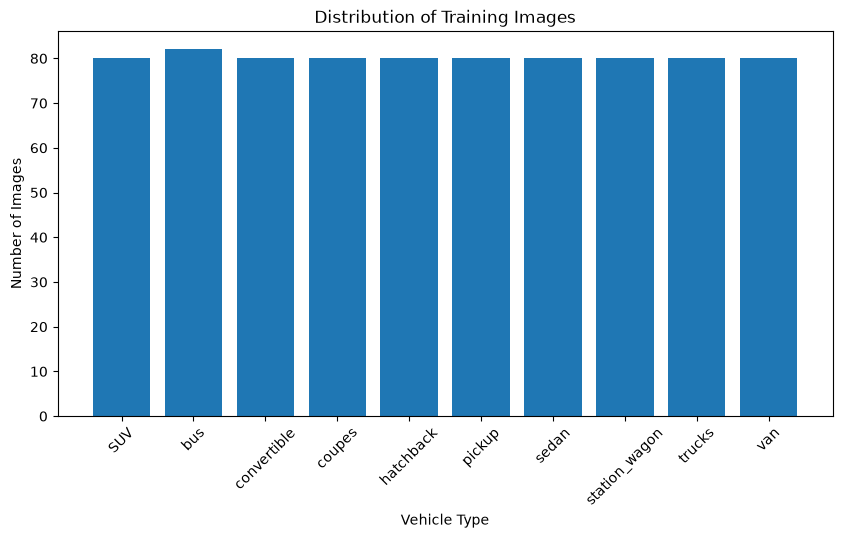

In [60]:
plt.figure(figsize=(10, 5))

plt.bar(class_counts.keys(), class_counts.values())

plt.xticks(rotation=45)
plt.xlabel("Vehicle Type")
plt.ylabel("Number of Images")
plt.title("Distribution of Training Images")

plt.show()


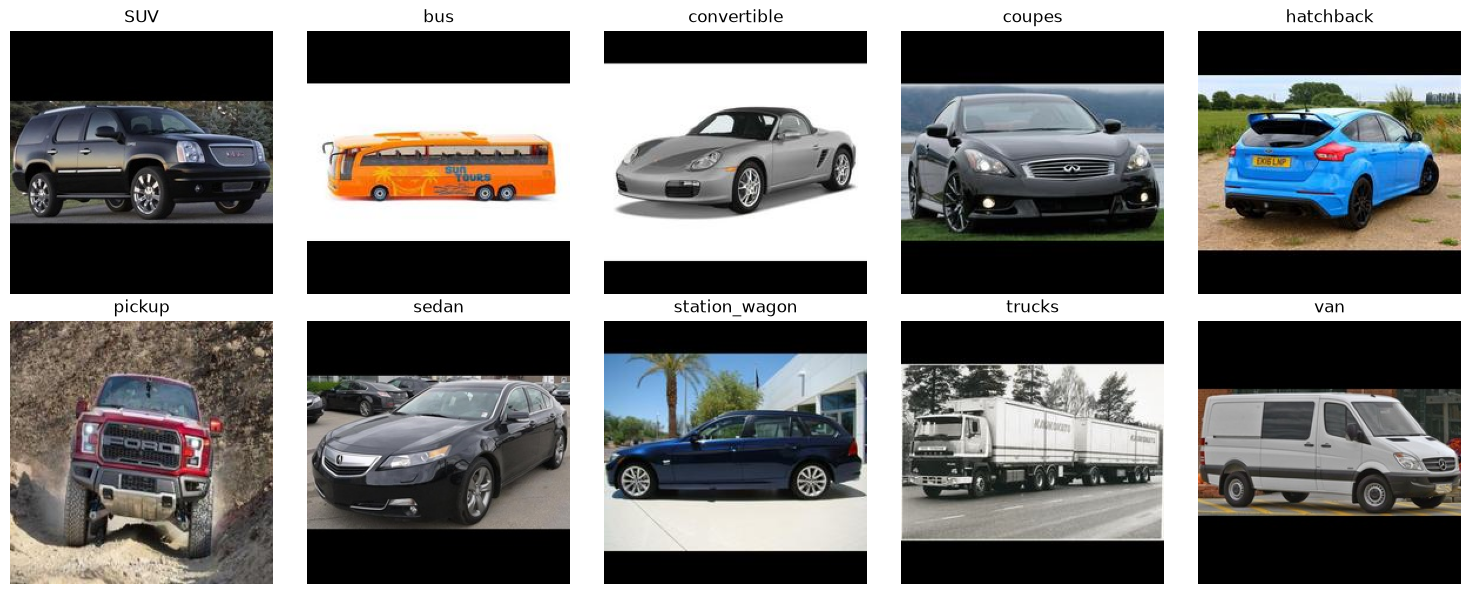

In [61]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for ax, class_name in zip(axes.flatten(), classes):
    class_path = os.path.join(train_dir, class_name)
    image_name = os.listdir(class_path)[0]
    image_path = os.path.join(class_path, image_name)

    image = Image.open(image_path)

    ax.imshow(image)
    ax.set_title(class_name)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [62]:
image_sizes = []

for class_name in classes:
    class_path = os.path.join(train_dir, class_name)

    for image_name in os.listdir(class_path):
        image_path = os.path.join(class_path, image_name)

        try:
            with Image.open(image_path) as image:
                image_sizes.append(image.size)
        except:
            pass

print("Jumlah gambar:", len(image_sizes))
print("Contoh ukuran:", image_sizes[:10])


Jumlah gambar: 802
Contoh ukuran: [(224, 224), (224, 224), (224, 224), (224, 224), (224, 224), (224, 224), (224, 224), (224, 224), (224, 224), (224, 224)]


In [63]:
from collections import Counter

size_counts = Counter(image_sizes)

print("Jumlah ukuran gambar berbeda:", len(size_counts))
print("\n5 ukuran paling sering:")

for size, count in size_counts.most_common(5):
    print(size, ":", count)

Jumlah ukuran gambar berbeda: 1

5 ukuran paling sering:
(224, 224) : 802


In [64]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset="training",
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset="validation",
    seed=SEED
)

print("Class names:")
print(train_ds.class_names)

Found 799 files belonging to 10 classes.
Using 640 files for training.
Found 799 files belonging to 10 classes.
Using 159 files for validation.
Class names:
['SUV', 'bus', 'convertible', 'coupes', 'hatchback', 'pickup', 'sedan', 'station_wagon', 'trucks', 'van']


In [65]:
print("Training batches:", len(train_ds))
print("Validation batches:", len(val_ds))

Training batches: 20
Validation batches: 5


In [66]:
images, labels = next(iter(train_ds))

print("Image shape:", images.shape)
print("Label shape:", labels.shape)
print("Pixel range:", images.numpy().min(), "-", images.numpy().max())

Image shape: (32, 224, 224, 3)
Label shape: (32,)
Pixel range: 0.0 - 255.0


In [67]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1)
])

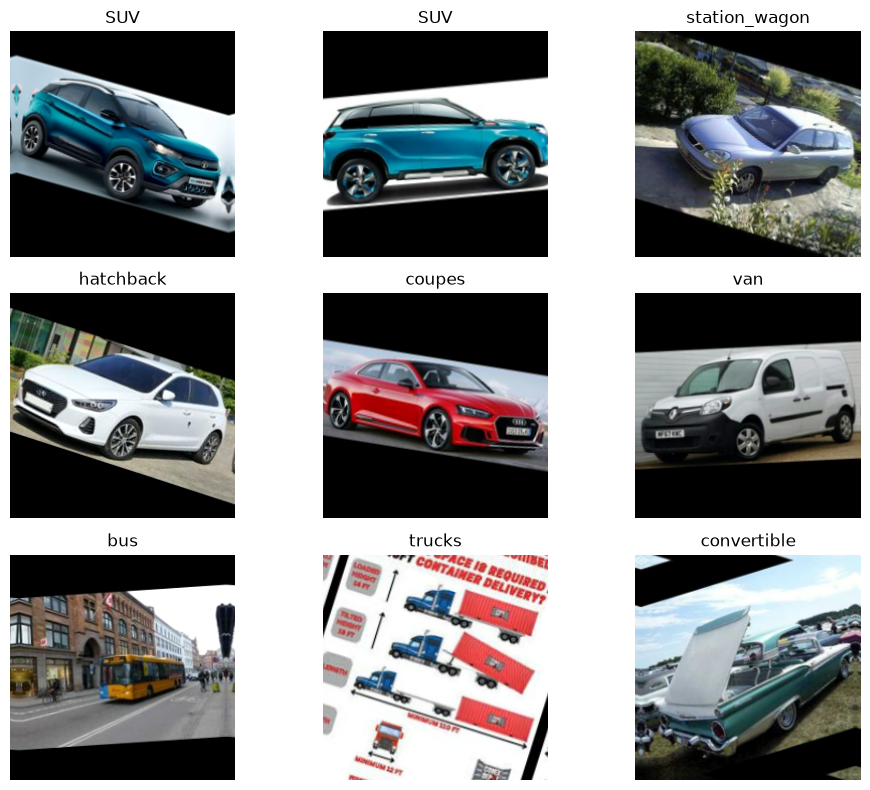

In [68]:
plt.figure(figsize=(10, 8))

for images, labels in train_ds.take(1):
    augmented_images = data_augmentation(images)

    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_images[i].numpy().astype("uint8"))
        plt.title(train_ds.class_names[labels[i]])
        plt.axis("off")

plt.tight_layout()
plt.show()

In [69]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

In [70]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

model = models.Sequential([
    data_augmentation,

    layers.Rescaling(1./127.5, offset=-1),

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dropout(0.3),

    layers.Dense(128, activation="relu"),

    layers.Dropout(0.2),

    layers.Dense(10, activation="softmax")
])

model.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_12 (Sequential)      │ (32, 224, 224, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_3 (Rescaling)         │ (32, 224, 224, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (32, 7, 7, 1280)       │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (32, 1280)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (32, 1280)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (32, 128)              │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (32, 128)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (32, 10)               │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [71]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [72]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        "../models/vehicle_mobilenetv2.keras",
        monitor="val_accuracy",
        save_best_only=True
    )
]

In [73]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20


d:\JamTerbang\DL\Klasifikasi Kendaraan\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


20/20 ━━━━━━━━━━━━━━━━━━━━ 19s 676ms/step - accuracy: 0.3203 - loss: 1.9713 - val_accuracy: 0.6730 - val_loss: 1.1838
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 589ms/step - accuracy: 0.6156 - loss: 1.1174 - val_accuracy: 0.7484 - val_loss: 0.7679
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 585ms/step - accuracy: 0.7094 - loss: 0.8726 - val_accuracy: 0.7862 - val_loss: 0.6299
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 566ms/step - accuracy: 0.7422 - loss: 0.6970 - val_accuracy: 0.7736 - val_loss: 0.6151
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 580ms/step - accuracy: 0.7547 - loss: 0.6725 - val_accuracy: 0.7925 - val_loss: 0.5688
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 572ms/step - accuracy: 0.7937 - loss: 0.5812 - val_accuracy: 0.8239 - val_loss: 0.5109
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 566ms/step - accuracy: 0.7984 - loss: 0.5433 - val_accuracy: 0.8239 - val_loss: 0.4621
Epoch 8/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 584ms/step - accuracy: 0.7891 - loss: 0.5444 - val_accuracy: 0.830

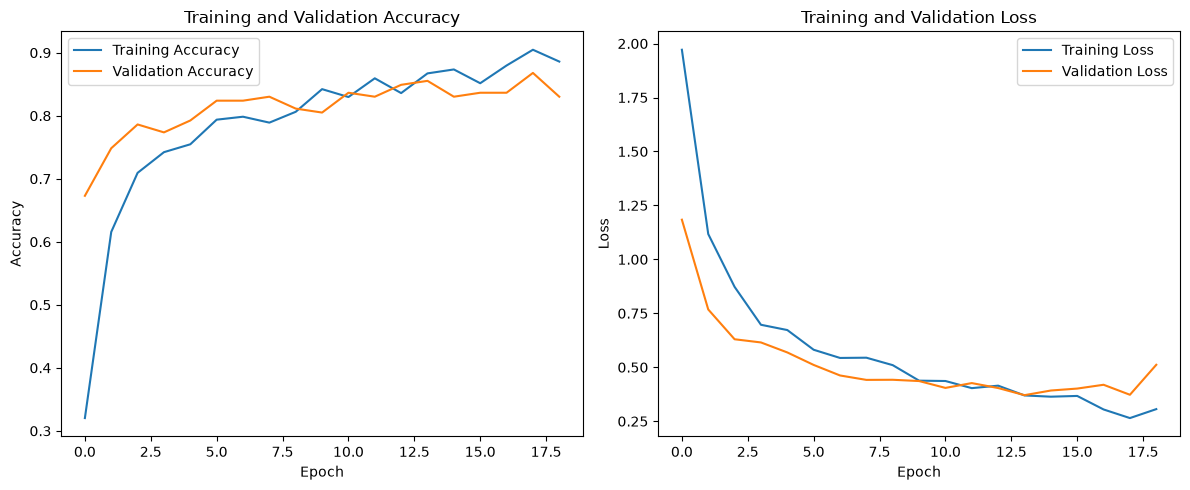

In [74]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [75]:
best_model = tf.keras.models.load_model(
    "../models/vehicle_mobilenetv2.keras"
)

print("Best model berhasil dimuat.")

Best model berhasil dimuat.


In [76]:
val_loss, val_accuracy = best_model.evaluate(val_ds)

print("Validation Loss:", val_loss)
print("Validation Accuracy:", val_accuracy)

5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 433ms/step - accuracy: 0.8679 - loss: 0.3726
Validation Loss: 0.3726487457752228
Validation Accuracy: 0.8679245114326477


In [77]:
fine_tune_model = tf.keras.models.load_model(
    "../models/vehicle_mobilenetv2.keras"
)

In [78]:
base_model = fine_tune_model.get_layer("mobilenetv2_1.00_224")

base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

for layer in base_model.layers[-20:]:
    layer.trainable = True

In [79]:
trainable_count = sum(
    layer.trainable for layer in base_model.layers
)

print("Total layer MobileNetV2:", len(base_model.layers))
print("Trainable layer:", trainable_count)

Total layer MobileNetV2: 154
Trainable layer: 20


In [80]:
fine_tune_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [81]:
fine_tune_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    
    tf.keras.callbacks.ModelCheckpoint(
        "../models/vehicle_mobilenetv2_finetuned.keras",
        monitor="val_accuracy",
        save_best_only=True
    )
]

In [82]:
fine_tune_history = fine_tune_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=fine_tune_callbacks
)

Epoch 1/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 24s 806ms/step - accuracy: 0.5609 - loss: 1.7364 - val_accuracy: 0.8553 - val_loss: 0.3936
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 713ms/step - accuracy: 0.6219 - loss: 1.3396 - val_accuracy: 0.8113 - val_loss: 0.4209
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 691ms/step - accuracy: 0.6578 - loss: 1.1130 - val_accuracy: 0.8050 - val_loss: 0.4461
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 650ms/step - accuracy: 0.7094 - loss: 0.9662 - val_accuracy: 0.8113 - val_loss: 0.4553
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 640ms/step - accuracy: 0.7344 - loss: 0.8373 - val_accuracy: 0.8113 - val_loss: 0.4610
Epoch 6/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 650ms/step - accuracy: 0.7625 - loss: 0.6976 - val_accuracy: 0.8176 - val_loss: 0.4612


In [83]:
print("Best fine-tuning model:")
print(
    fine_tune_model.evaluate(
        val_ds,
        verbose=1
    )
)

Best fine-tuning model:
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 483ms/step - accuracy: 0.8553 - loss: 0.3936
[0.3935944139957428, 0.8553459048271179]


In [84]:
best_fine_tuned = tf.keras.models.load_model(
    "../models/vehicle_mobilenetv2_finetuned.keras"
)

fine_loss, fine_accuracy = best_fine_tuned.evaluate(
    val_ds,
    verbose=1
)

print("Fine-tuning Validation Loss:", fine_loss)
print("Fine-tuning Validation Accuracy:", fine_accuracy)

5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 491ms/step - accuracy: 0.8553 - loss: 0.3936
Fine-tuning Validation Loss: 0.3935943841934204
Fine-tuning Validation Accuracy: 0.8553459048271179


In [85]:
print("=== MODEL COMPARISON ===")

print(f"Baseline MobileNetV2 : {val_accuracy:.4f}")
print(f"Fine-Tuning MobileNetV2 : {fine_accuracy:.4f}")

=== MODEL COMPARISON ===
Baseline MobileNetV2 : 0.8679
Fine-Tuning MobileNetV2 : 0.8553


In [87]:
class_names = [
    "SUV",
    "bus",
    "convertible",
    "coupes",
    "hatchback",
    "pickup",
    "sedan",
    "station_wagon",
    "trucks",
    "van"
]

print(class_names)

['SUV', 'bus', 'convertible', 'coupes', 'hatchback', 'pickup', 'sedan', 'station_wagon', 'trucks', 'van']


In [89]:
from sklearn.metrics import classification_report
import numpy as np

y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = best_model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

               precision    recall  f1-score   support

          SUV       0.74      0.82      0.78        17
          bus       0.95      1.00      0.97        19
  convertible       0.93      0.87      0.90        15
       coupes       0.78      0.54      0.64        13
    hatchback       1.00      1.00      1.00        16
       pickup       1.00      0.81      0.90        16
        sedan       0.62      0.72      0.67        18
station_wagon       0.80      0.92      0.86        13
       trucks       1.00      0.95      0.97        20
          van       0.92      1.00      0.96        12

     accuracy                           0.87       159
    macro avg       0.87      0.86      0.86       159
 weighted avg       0.88      0.87      0.87       159



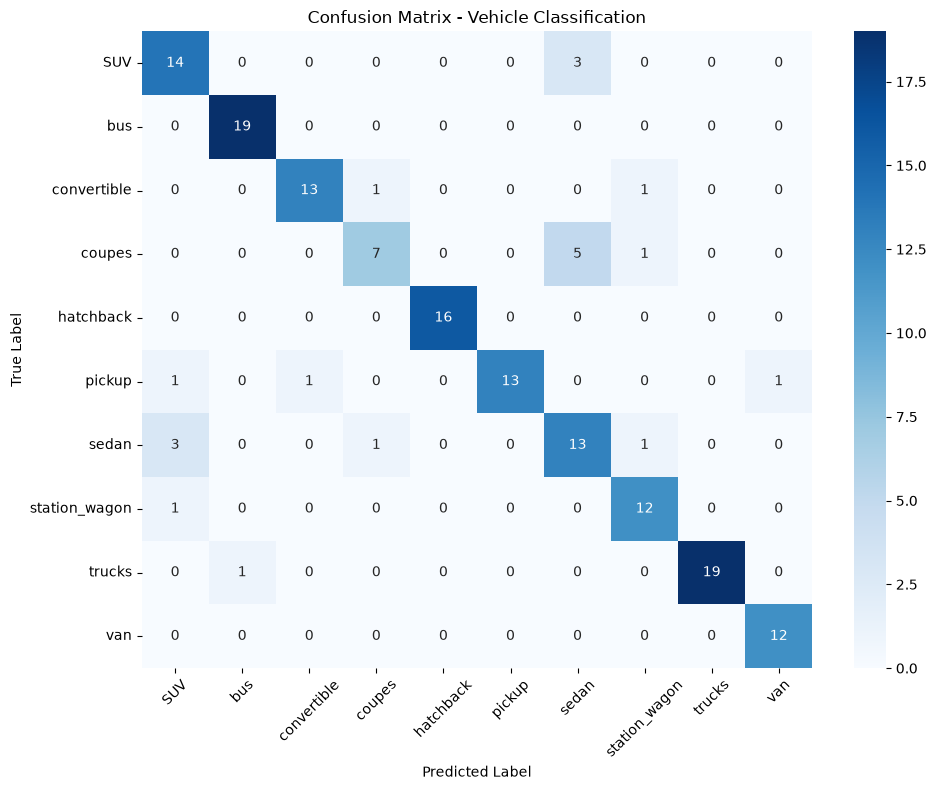

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Vehicle Classification")
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
model = tf.keras.models.load_model(
    "../models/vehicle_mobilenetv2_finetuned.keras"
)

model.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_12 (Sequential)      │ (32, 224, 224, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_3 (Rescaling)         │ (32, 224, 224, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (32, 7, 7, 1280)       │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (32, 1280)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (32, 1280)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (32, 128)              │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (32, 128)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (32, 10)               │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,165,920 (19.71 MB)

 Trainable params: 1,371,338 (5.23 MB)

 Non-trainable params: 1,051,904 (4.01 MB)

 Optimizer params: 2,742,678 (10.46 MB)

In [93]:
base_model = model.get_layer("mobilenetv2_1.00_224")

print("Jumlah layer:", len(base_model.layers))
print("Trainable:", base_model.trainable)

Jumlah layer: 154
Trainable: True


In [94]:
class_names = [
    "SUV",
    "bus",
    "convertible",
    "coupes",
    "hatchback",
    "pickup",
    "sedan",
    "station_wagon",
    "trucks",
    "van"
]

In [95]:
loss, accuracy = model.evaluate(val_ds)

print("Fine-tuned Validation Loss:", loss)
print("Fine-tuned Validation Accuracy:", accuracy)

5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 483ms/step - accuracy: 0.8553 - loss: 0.3936
Fine-tuned Validation Loss: 0.3935943841934204
Fine-tuned Validation Accuracy: 0.8553459048271179


In [96]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

               precision    recall  f1-score   support

          SUV       0.70      0.82      0.76        17
          bus       0.95      1.00      0.97        19
  convertible       0.93      0.87      0.90        15
       coupes       0.88      0.54      0.67        13
    hatchback       1.00      0.94      0.97        16
       pickup       1.00      0.81      0.90        16
        sedan       0.57      0.72      0.63        18
station_wagon       0.79      0.85      0.81        13
       trucks       1.00      0.95      0.97        20
          van       0.92      1.00      0.96        12

     accuracy                           0.86       159
    macro avg       0.87      0.85      0.85       159
 weighted avg       0.87      0.86      0.86       159



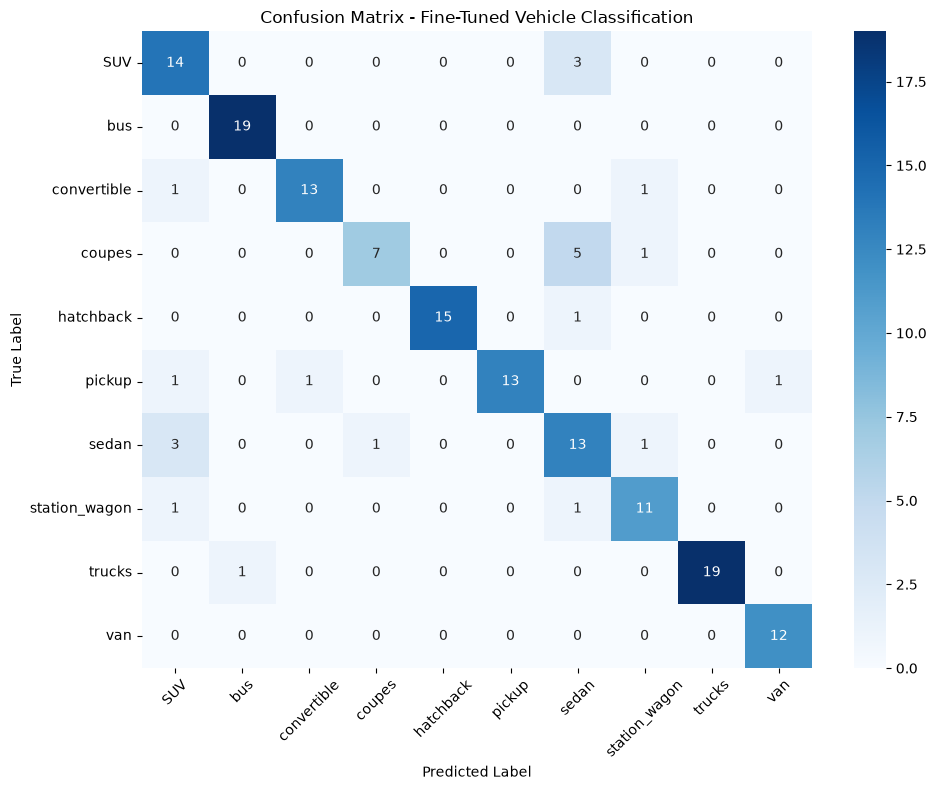

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix - Fine-Tuned Vehicle Classification")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [99]:
baseline_model = tf.keras.models.load_model(
    "../models/vehicle_mobilenetv2.keras"
)

print("Baseline model loaded.")

Baseline model loaded.


In [100]:
wrong_images = []
wrong_true = []
wrong_pred = []
wrong_conf = []

for images, labels in val_ds:
    predictions = baseline_model.predict(images, verbose=0)

    pred_labels = np.argmax(predictions, axis=1)
    confidences = np.max(predictions, axis=1)

    for i in range(len(labels)):
        true_label = labels[i].numpy()
        pred_label = pred_labels[i]

        if true_label != pred_label:
            wrong_images.append(images[i].numpy())
            wrong_true.append(true_label)
            wrong_pred.append(pred_label)
            wrong_conf.append(confidences[i])

print("Jumlah prediksi salah:", len(wrong_images))

Jumlah prediksi salah: 21


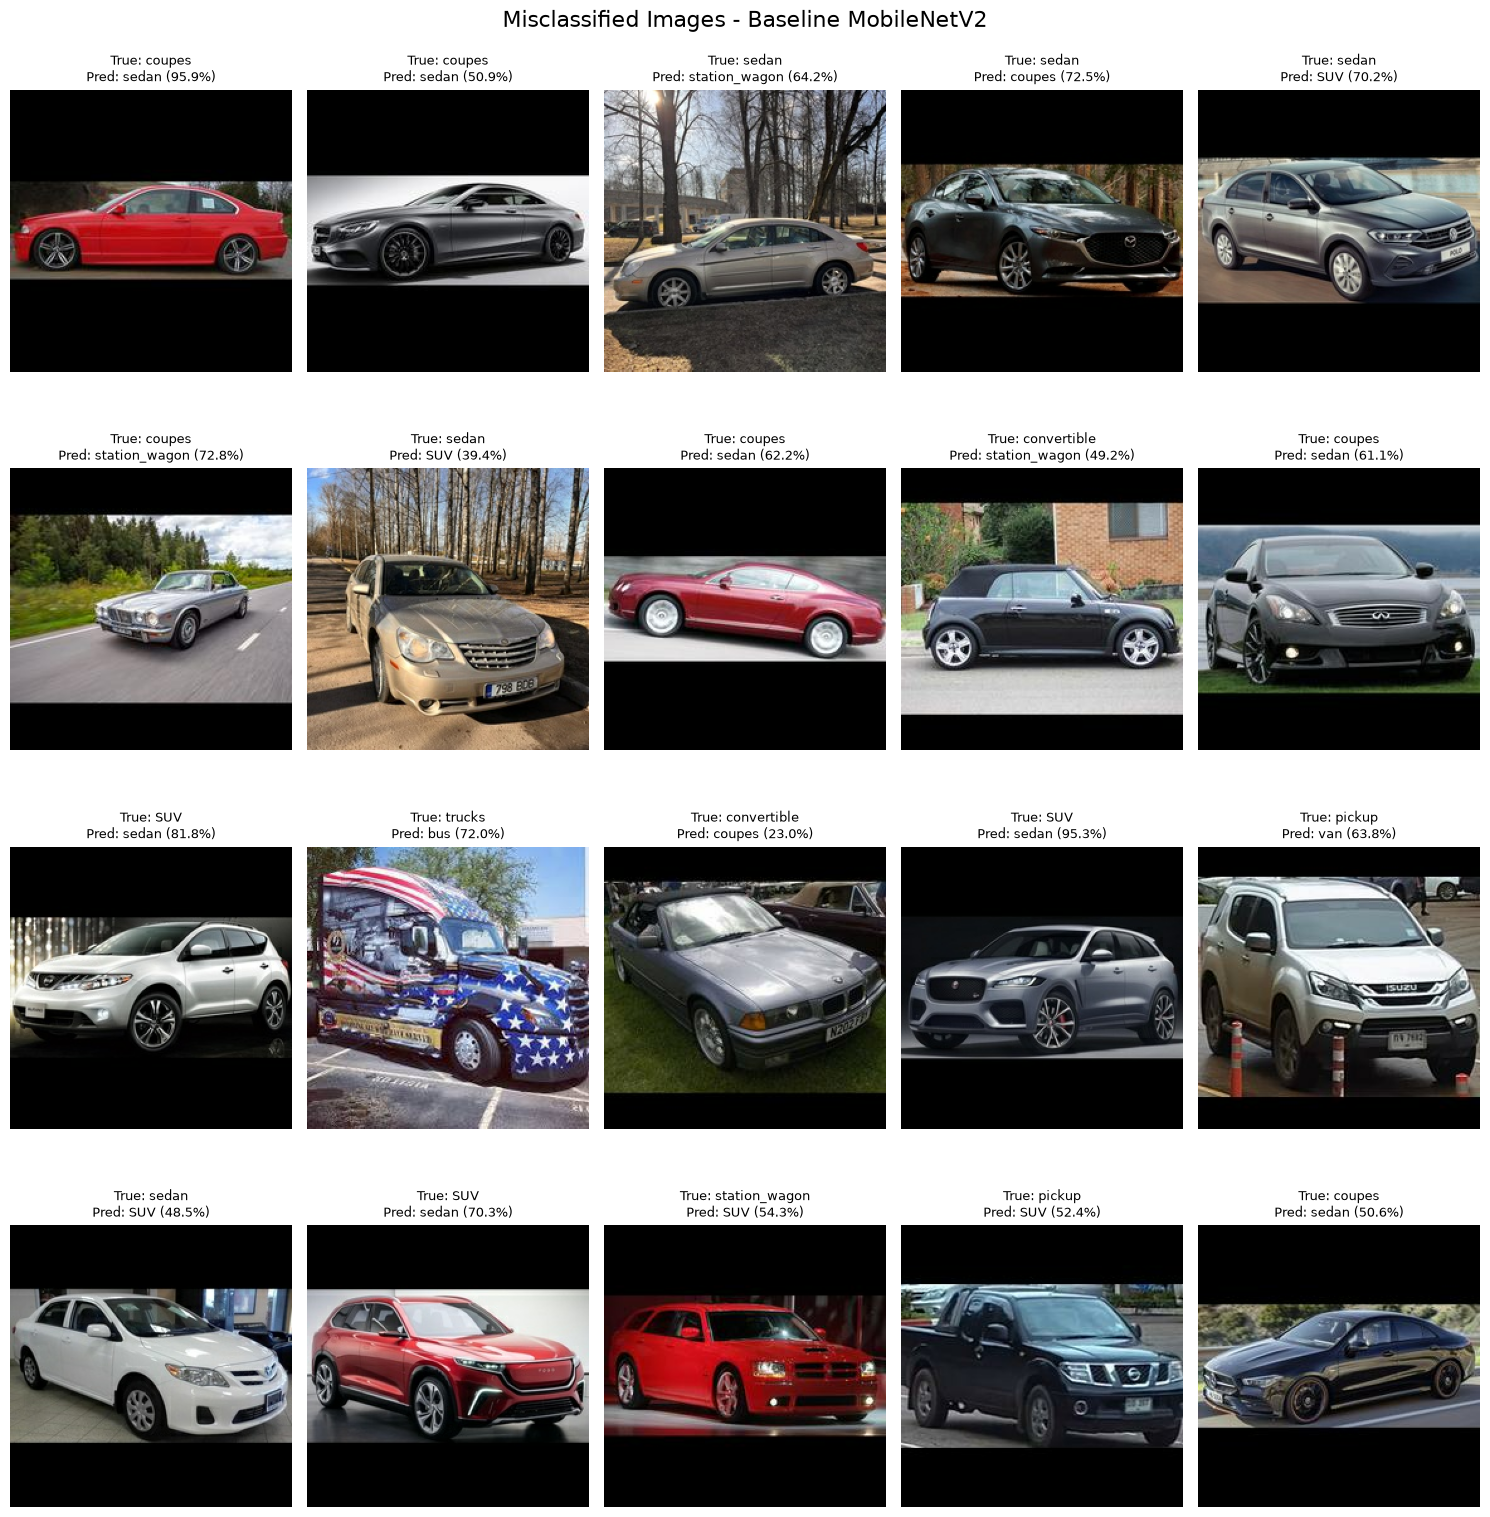

In [102]:
num_images = min(20, len(wrong_images))

plt.figure(figsize=(15, 16))

for i in range(num_images):
    plt.subplot(4, 5, i + 1)

    image = wrong_images[i]

    # Pastikan nilai gambar berada pada 0-1
    if image.max() > 1:
        image = image / 255.0

    plt.imshow(image)

    true_name = class_names[wrong_true[i]]
    pred_name = class_names[wrong_pred[i]]
    confidence = wrong_conf[i] * 100

    plt.title(
        f"True: {true_name}\n"
        f"Pred: {pred_name} ({confidence:.1f}%)",
        fontsize=9
    )

    plt.axis("off")

plt.suptitle(
    "Misclassified Images - Baseline MobileNetV2",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [103]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6
    ),
    tf.keras.callbacks.ModelCheckpoint(
        "../models/vehicle_mobilenetv2_augmented.keras",
        monitor="val_accuracy",
        save_best_only=True
    )
]

In [104]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20


d:\JamTerbang\DL\Klasifikasi Kendaraan\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


20/20 ━━━━━━━━━━━━━━━━━━━━ 17s 702ms/step - accuracy: 0.5938 - loss: 1.4552 - val_accuracy: 0.8113 - val_loss: 0.4184 - learning_rate: 1.0000e-05
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 15s 733ms/step - accuracy: 0.6719 - loss: 1.0510 - val_accuracy: 0.8050 - val_loss: 0.4373 - learning_rate: 1.0000e-05
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 723ms/step - accuracy: 0.7063 - loss: 0.9299 - val_accuracy: 0.8113 - val_loss: 0.4604 - learning_rate: 1.0000e-05
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 703ms/step - accuracy: 0.7344 - loss: 0.8319 - val_accuracy: 0.8113 - val_loss: 0.4676 - learning_rate: 5.0000e-06


In [105]:
model = tf.keras.models.load_model(
    "../models/vehicle_mobilenetv2.keras"
)

In [ ]:
best_model = tf.keras.models.load_model(
    "../models/vehicle_mobilenetv2.keras"
)

print("Model final berhasil dimuat.")

Model final berhasil dimuat.


In [108]:
def predict_vehicle(image_path):
    image = tf.keras.utils.load_img(
        image_path,
        target_size=(224, 224)
    )

    image_array = tf.keras.utils.img_to_array(image)
    image_array = tf.expand_dims(image_array, 0)

    predictions = best_model.predict(
        image_array,
        verbose=0
    )

    predicted_index = np.argmax(predictions[0])
    confidence = predictions[0][predicted_index]

    print("Predicted Vehicle :", class_names[predicted_index])
    print("Confidence        :", f"{confidence * 100:.2f}%")

    plt.figure(figsize=(5, 5))
    plt.imshow(image)
    plt.title(
        f"{class_names[predicted_index]}\n"
        f"Confidence: {confidence * 100:.2f}%"
    )
    plt.axis("off")
    plt.show()

In [109]:
import os

test_path = "../dataset/vehicle-type-10/test"

files = os.listdir(test_path)

print("Jumlah file:", len(files))
print("5 file pertama:")
print(files[:5])

Jumlah file: 201
5 file pertama:
['0009.jpg', '0013.jpg', '0024.jpg', '0028.jpg', '0034.jpg']


Predicted Vehicle : van
Confidence        : 99.66%


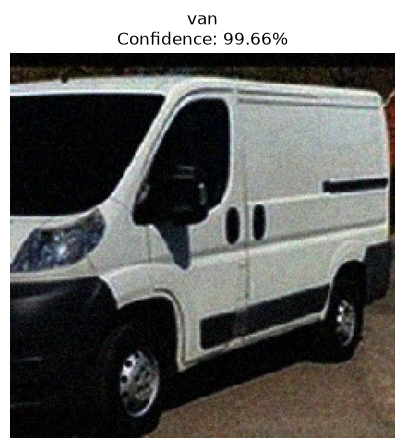

In [121]:
predict_vehicle(
    "../dataset/vehicle-type-10/test/0968.jpg"
)

In [122]:
# Evaluasi model final
final_loss, final_accuracy = best_model.evaluate(
    val_ds,
    verbose=1
)

print(f"Final Validation Loss     : {final_loss:.4f}")
print(f"Final Validation Accuracy : {final_accuracy:.4f}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 448ms/step - accuracy: 0.8679 - loss: 0.3726
Final Validation Loss     : 0.3726
Final Validation Accuracy : 0.8679


In [123]:
final_model_path = "../models/vehicle_mobilenetv2_final.keras"

model.save(final_model_path)

print(f"Model final berhasil disimpan di: {final_model_path}")

Model final berhasil disimpan di: ../models/vehicle_mobilenetv2_final.keras
